# Análise do LastFM dataset

Notebook para análise dos dados do dataset LastFM.

## Bibliotecas

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.ticker import PercentFormatter

In [2]:
path = "../data/processed/lastfm/lastfm.user"

## Estatísticas descritivas

Total users: 267,341

gender
Male               197,886 ( 74.02%)
Female              69,455 ( 25.98%)
Unknown                  0 (  0.00%)



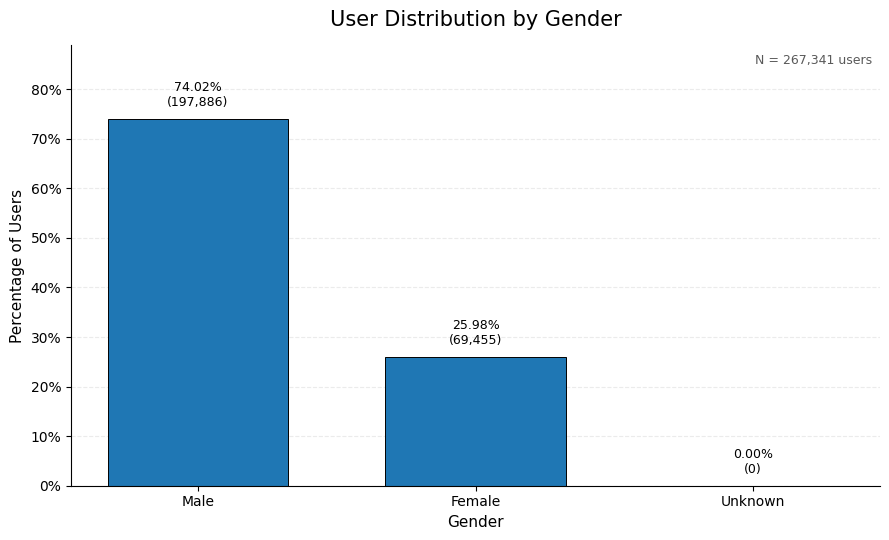

age
Under 18            20,101 (  7.52%)
18–24              139,633 ( 52.23%)
25–34               79,764 ( 29.84%)
35–44               19,152 (  7.16%)
45–49                3,330 (  1.25%)
50–55                2,230 (  0.83%)
Over 55              3,131 (  1.17%)
Unknown                  0 (  0.00%)



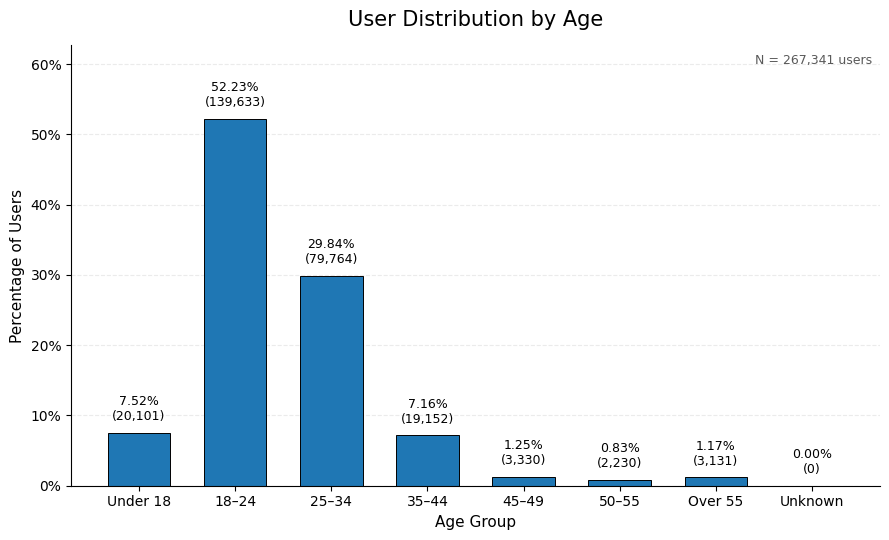

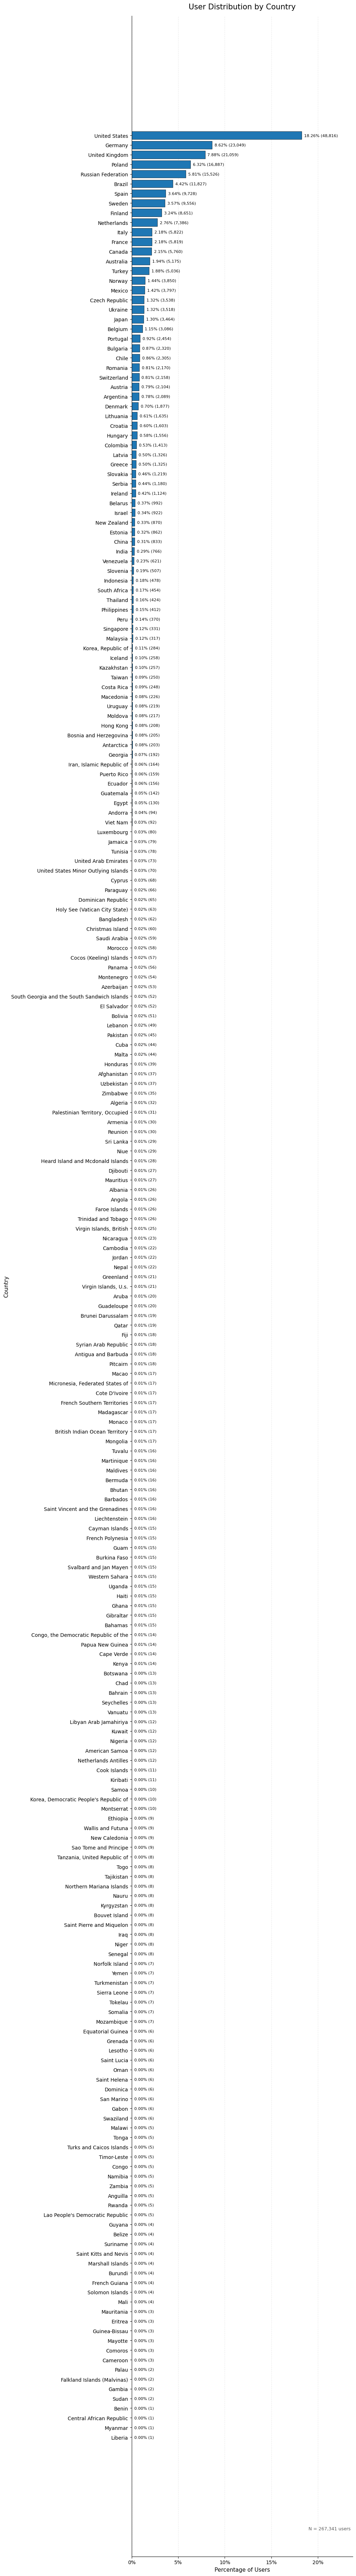

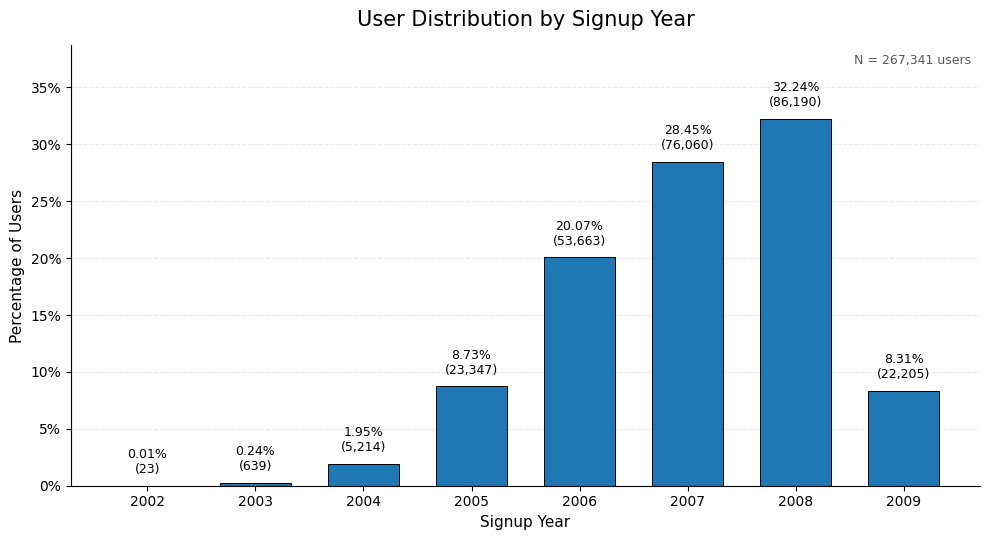

In [3]:
# ============================================================
# Group definitions
# ============================================================

def _gender_group(value: str | None) -> str:
    if value is None or pd.isna(value):
        return "unknown"

    normalized = str(value).strip().casefold()

    if normalized in {"m", "male"}:
        return "male"

    if normalized in {"f", "female"}:
        return "female"

    return "unknown"


def _age_group(age: float | None) -> str:
    if age is None or pd.isna(age):
        return "unknown"

    if age < 18:
        return "under_18"

    if age <= 24:
        return "18_24"

    if age <= 34:
        return "25_34"

    if age <= 44:
        return "35_44"

    if age <= 49:
        return "45_49"

    if age <= 55:
        return "50_55"

    return "over_55"


def _country_group(value: str | None) -> str:
    if value is None or pd.isna(value):
        return "unknown"

    normalized = str(value).strip()

    if not normalized:
        return "unknown"

    return normalized


# ============================================================
# Data preparation
# ============================================================

def load_users(file_path: str) -> pd.DataFrame:
    df = pd.read_csv(
        file_path,
        sep="\t",
    )

    # Remove RecBole type suffixes:
    # user_id:token     -> user_id
    # gender:token      -> gender
    # age:float         -> age
    # country:token     -> country
    # signup_date:token -> signup_date
    df.columns = [
        column.split(":")[0]
        for column in df.columns
    ]

    df["age"] = pd.to_numeric(
        df["age"],
        errors="coerce",
    )

    df["signup_date"] = pd.to_datetime(
        df["signup_date"],
        errors="coerce",
    )

    # --------------------------------------------------------
    # Create groups
    # --------------------------------------------------------

    df["gender_group"] = (
        df["gender"]
        .apply(_gender_group)
    )

    df["age_group"] = (
        df["age"]
        .apply(_age_group)
    )

    df["country_group"] = (
        df["country"]
        .apply(_country_group)
    )

    # Signup year
    df["signup_year_group"] = (
        df["signup_date"]
        .dt.year
        .astype("Int64")
        .astype(str)
        .replace("<NA>", "unknown")
    )

    return df


# ============================================================
# Plot configuration
# ============================================================

AGE_ORDER = [
    "under_18",
    "18_24",
    "25_34",
    "35_44",
    "45_49",
    "50_55",
    "over_55",
    "unknown",
]


GROUP_CONFIG = {
    "gender": {
        "column": "gender_group",
        "order": [
            "male",
            "female",
            "unknown",
        ],
        "labels": {
            "male": "Male",
            "female": "Female",
            "unknown": "Unknown",
        },
        "title": "User Distribution by Gender",
        "xlabel": "Gender",
        "filename": "gender_distribution",
    },

    "age": {
        "column": "age_group",
        "order": AGE_ORDER,
        "labels": {
            "under_18": "Under 18",
            "18_24": "18–24",
            "25_34": "25–34",
            "35_44": "35–44",
            "45_49": "45–49",
            "50_55": "50–55",
            "over_55": "Over 55",
            "unknown": "Unknown",
        },
        "title": "User Distribution by Age",
        "xlabel": "Age Group",
        "filename": "age_distribution",
    },
}


# ============================================================
# Standard vertical bar plot
# ============================================================

def plot_group_distribution(
    df: pd.DataFrame,
    config: dict,
    output_dir: Path | None = None,
):
    column = config["column"]
    order = config["order"]
    labels = config["labels"]

    counts = (
        df[column]
        .value_counts()
        .reindex(
            order,
            fill_value=0,
        )
    )

    total = counts.sum()

    percentages = (
        counts / total * 100
    )

    x_labels = [
        labels[group]
        for group in order
    ]

    fig, ax = plt.subplots(
        figsize=(9, 5.5)
    )

    bars = ax.bar(
        x_labels,
        percentages,
        width=0.65,
        edgecolor="black",
        linewidth=0.7,
    )

    # --------------------------------------------------------
    # Labels above bars
    # --------------------------------------------------------

    max_percentage = percentages.max()

    for bar, count, percentage in zip(
        bars,
        counts,
        percentages,
    ):
        ax.annotate(
            f"{percentage:.2f}%\n({count:,})",
            xy=(
                bar.get_x()
                + bar.get_width() / 2,
                bar.get_height(),
            ),
            xytext=(0, 7),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=9,
        )

    # --------------------------------------------------------
    # Appearance
    # --------------------------------------------------------

    ax.set_title(
        config["title"],
        fontsize=15,
        pad=14,
    )

    ax.set_xlabel(
        config["xlabel"],
        fontsize=11,
    )

    ax.set_ylabel(
        "Percentage of Users",
        fontsize=11,
    )

    ax.yaxis.set_major_formatter(
        PercentFormatter(
            xmax=100,
            decimals=0,
        )
    )

    ax.set_ylim(
        0,
        max_percentage * 1.20,
    )

    ax.grid(
        axis="y",
        linestyle="--",
        alpha=0.25,
    )

    ax.set_axisbelow(True)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.text(
        0.99,
        0.98,
        f"N = {total:,} users",
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=9,
        alpha=0.65,
    )

    plt.tight_layout()

    # --------------------------------------------------------
    # Save
    # --------------------------------------------------------

    if output_dir is not None:
        output_dir.mkdir(
            parents=True,
            exist_ok=True,
        )

        base_path = (
            output_dir
            / config["filename"]
        )

        fig.savefig(
            base_path.with_suffix(".png"),
            dpi=300,
            bbox_inches="tight",
        )

        fig.savefig(
            base_path.with_suffix(".pdf"),
            bbox_inches="tight",
        )

    plt.show()
    plt.close(fig)


# ============================================================
# Country distribution
# ============================================================

def plot_country_distribution(
    df: pd.DataFrame,
    output_dir: Path | None = None,
):
    counts = (
        df["country_group"]
        .value_counts()
    )

    total = counts.sum()

    percentages = (
        counts / total * 100
    )

    # Dynamic height because there may be many countries
    height = max(
        6,
        len(counts) * 0.30,
    )

    fig, ax = plt.subplots(
        figsize=(10, height)
    )

    bars = ax.barh(
        counts.index,
        percentages,
        edgecolor="black",
        linewidth=0.5,
    )

    # Largest country at the top
    ax.invert_yaxis()

    max_percentage = percentages.max()

    for bar, count, percentage in zip(
        bars,
        counts,
        percentages,
    ):
        ax.annotate(
            f"{percentage:.2f}% ({count:,})",
            xy=(
                bar.get_width(),
                bar.get_y()
                + bar.get_height() / 2,
            ),
            xytext=(5, 0),
            textcoords="offset points",
            ha="left",
            va="center",
            fontsize=8,
        )

    ax.set_title(
        "User Distribution by Country",
        fontsize=15,
        pad=14,
    )

    ax.set_xlabel(
        "Percentage of Users",
        fontsize=11,
    )

    ax.set_ylabel(
        "Country",
        fontsize=11,
    )

    ax.xaxis.set_major_formatter(
        PercentFormatter(
            xmax=100,
            decimals=0,
        )
    )

    ax.set_xlim(
        0,
        max_percentage * 1.30,
    )

    ax.grid(
        axis="x",
        linestyle="--",
        alpha=0.25,
    )

    ax.set_axisbelow(True)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.text(
        0.99,
        0.01,
        f"N = {total:,} users",
        transform=ax.transAxes,
        ha="right",
        va="bottom",
        fontsize=9,
        alpha=0.65,
    )

    plt.tight_layout()

    if output_dir is not None:
        output_dir.mkdir(
            parents=True,
            exist_ok=True,
        )

        base_path = (
            output_dir
            / "country_distribution"
        )

        fig.savefig(
            base_path.with_suffix(".png"),
            dpi=300,
            bbox_inches="tight",
        )

        fig.savefig(
            base_path.with_suffix(".pdf"),
            bbox_inches="tight",
        )

    plt.show()
    plt.close(fig)


# ============================================================
# Signup year distribution
# ============================================================

def plot_signup_year_distribution(
    df: pd.DataFrame,
    output_dir: Path | None = None,
):
    valid_years = (
        df.loc[
            df["signup_year_group"] != "unknown",
            "signup_year_group",
        ]
        .astype(int)
    )

    year_counts = (
        valid_years
        .value_counts()
        .sort_index()
    )

    unknown_count = (
        df["signup_year_group"]
        == "unknown"
    ).sum()

    # Add unknown at the end if present
    labels = [
        str(year)
        for year in year_counts.index
    ]

    counts = list(
        year_counts.values
    )

    if unknown_count > 0:
        labels.append("Unknown")
        counts.append(unknown_count)

    counts = pd.Series(
        counts,
        index=labels,
    )

    total = counts.sum()

    percentages = (
        counts / total * 100
    )

    fig, ax = plt.subplots(
        figsize=(10, 5.5)
    )

    bars = ax.bar(
        counts.index,
        percentages,
        width=0.65,
        edgecolor="black",
        linewidth=0.7,
    )

    max_percentage = percentages.max()

    for bar, count, percentage in zip(
        bars,
        counts,
        percentages,
    ):
        ax.annotate(
            f"{percentage:.2f}%\n({count:,})",
            xy=(
                bar.get_x()
                + bar.get_width() / 2,
                bar.get_height(),
            ),
            xytext=(0, 7),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=9,
        )

    ax.set_title(
        "User Distribution by Signup Year",
        fontsize=15,
        pad=14,
    )

    ax.set_xlabel(
        "Signup Year",
        fontsize=11,
    )

    ax.set_ylabel(
        "Percentage of Users",
        fontsize=11,
    )

    ax.yaxis.set_major_formatter(
        PercentFormatter(
            xmax=100,
            decimals=0,
        )
    )

    ax.set_ylim(
        0,
        max_percentage * 1.20,
    )

    ax.grid(
        axis="y",
        linestyle="--",
        alpha=0.25,
    )

    ax.set_axisbelow(True)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.text(
        0.99,
        0.98,
        f"N = {total:,} users",
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=9,
        alpha=0.65,
    )

    plt.tight_layout()

    if output_dir is not None:
        output_dir.mkdir(
            parents=True,
            exist_ok=True,
        )

        base_path = (
            output_dir
            / "signup_year_distribution"
        )

        fig.savefig(
            base_path.with_suffix(".png"),
            dpi=300,
            bbox_inches="tight",
        )

        fig.savefig(
            base_path.with_suffix(".pdf"),
            bbox_inches="tight",
        )

    plt.show()
    plt.close(fig)


# ============================================================
# Generate all plots
# ============================================================

def plot_all_user_metadata(
    file_path: str,
    output_dir: str = "plots/user_metadata",
):
    df = load_users(file_path)

    output_path = Path(output_dir)

    print(f"Total users: {len(df):,}")
    print()

    # Gender and age
    for metadata, config in GROUP_CONFIG.items():
        print("=" * 60)
        print(metadata)
        print("=" * 60)

        counts = (
            df[config["column"]]
            .value_counts()
            .reindex(
                config["order"],
                fill_value=0,
            )
        )

        percentages = (
            counts / counts.sum() * 100
        )

        for group in config["order"]:
            label = config["labels"][group]

            print(
                f"{label:<15} "
                f"{counts[group]:>10,} "
                f"({percentages[group]:>6.2f}%)"
            )

        print()

        plot_group_distribution(
            df=df,
            config=config,
            output_dir=output_path,
        )

    # Country
    plot_country_distribution(
        df=df,
        output_dir=output_path,
    )

    # Signup year
    plot_signup_year_distribution(
        df=df,
        output_dir=output_path,
    )


# ============================================================
# Example
# ============================================================

plot_all_user_metadata(
    file_path=path,
    output_dir="plots/lastfm/user_metadata",
)